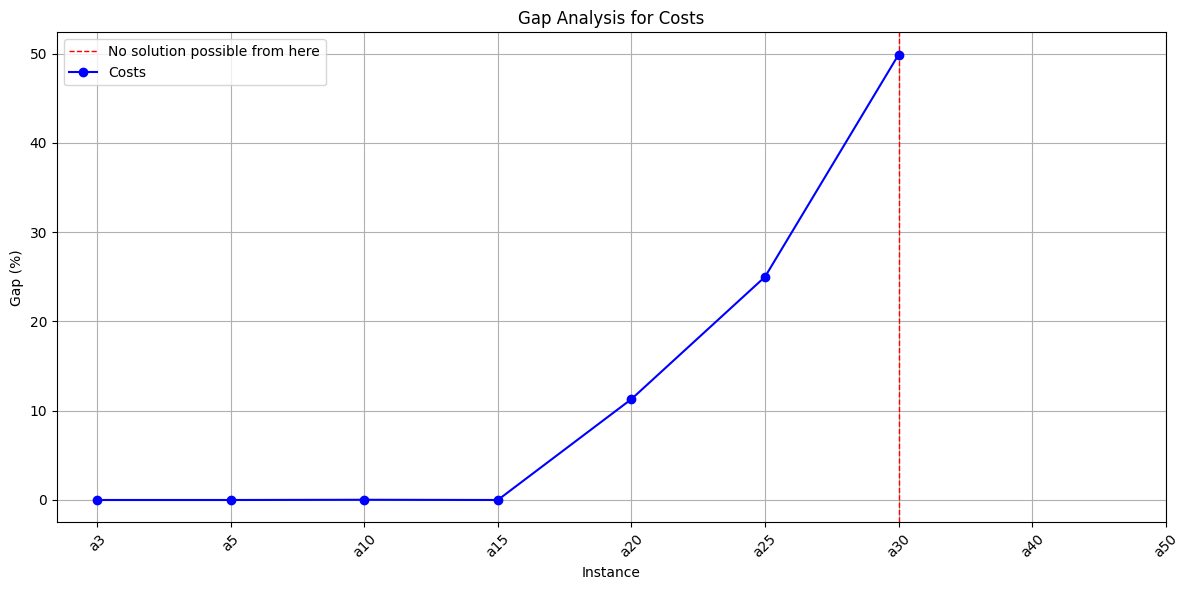

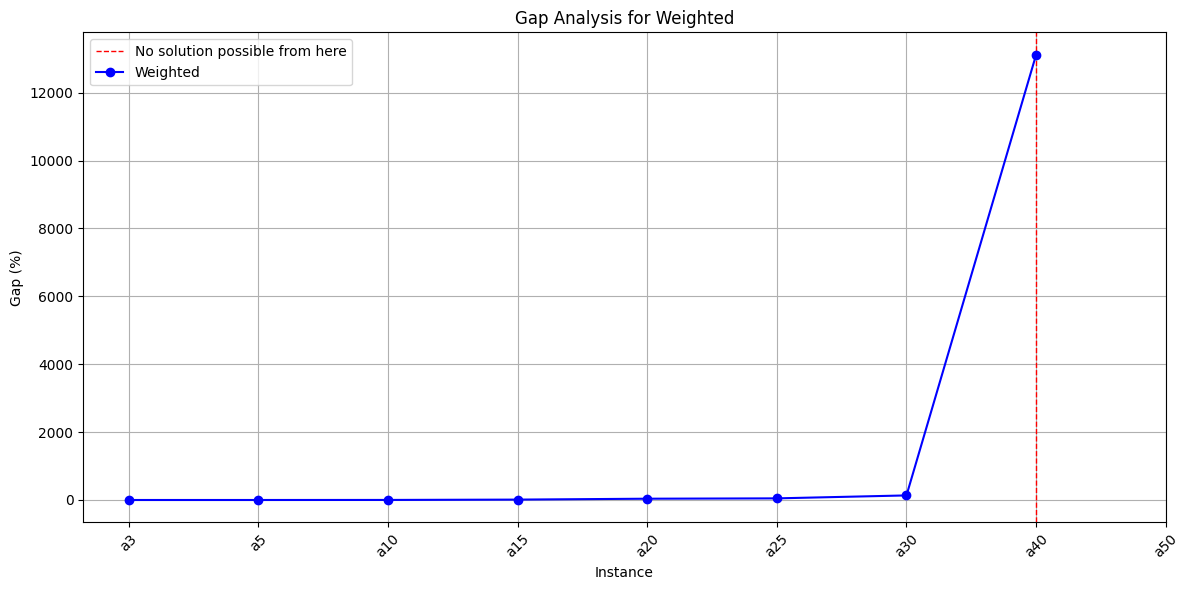

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# Daten laden
file_path = "filtered_data.csv"
df = pd.read_csv(file_path)

# Instanzennamen bereinigen (nur "a" + Zahl)
df["Instance"] = df["Instance"].str.extract(r"(a\d+)", expand=False)

# Fehlende Lösungen prüfen
df["Gap (%)"] = df["Gap (%)"].replace("-", 0).astype(float)
df["Missing Solution"] = (df["Gap (%)"] == 0) & (df["Construction Fulfillment"] == "-")

# Durchschnittliche Gaps für a10 berechnen und in den DataFrame einfügen
a10_instances = df[df["Instance"] == "a10"]
a10_avg_gap = a10_instances.groupby("Method")["Gap (%)"].mean()

# Filter für andere Instanzen (ohne "a10")
df = df[df["Instance"] != "a10"]

# Durchschnittswerte für "a10" hinzufügen
for method in ["costs", "weighted"]:
    avg_gap = a10_avg_gap.get(method, 0)
    missing_solution_a10 = all(a10_instances[a10_instances["Method"] == method]["Missing Solution"])
    df = pd.concat([
        df,
        pd.DataFrame({
            "Instance": ["a10"],
            "Method": [method],
            "Gap (%)": [avg_gap if not missing_solution_a10 else 0],
            "Missing Solution": [missing_solution_a10],
        })
    ])

# Instanzsortierung hinzufügen
df["Instance_Sort"] = df["Instance"].str.extract(r"(\d+)").astype(int)
df = df.sort_values(by=["Instance_Sort", "Method"]).reset_index(drop=True)

# Liste der tatsächlich in der CSV-Datei vorhandenen Instanzen (sortiert)
all_instances = sorted(df["Instance"].unique(), key=lambda x: int(x[1:]))

# Plot für jede Methode
for method in ["costs", "weighted"]:
    method_data = df[df["Method"] == method].reset_index(drop=True)
    
    # Prüfen, ab welcher Instanz keine Lösung mehr möglich ist
    first_missing_solution = method_data[method_data["Missing Solution"]].iloc[0] if not method_data[method_data["Missing Solution"]].empty else None
    
    # Falls es fehlende Lösungen gibt, berechne den Startpunkt der roten Linie
    if first_missing_solution is not None:
        cutoff_instance_sort = max(first_missing_solution["Instance_Sort"] - 10, method_data["Instance_Sort"].min())
        # Filter für Instanzen bis zur letzten gültigen Instanz
        method_data = method_data[method_data["Instance_Sort"] < first_missing_solution["Instance_Sort"]]
    else:
        cutoff_instance_sort = None
    
    plt.figure(figsize=(12, 6))
    
    # Gestrichelte rote Linie mit Beschriftung
    if cutoff_instance_sort is not None:
        plt.axvline(
            x=all_instances.index(f"a{cutoff_instance_sort}"),
            color="red",
            linestyle="--",
            linewidth=1,
            label="No solution possible from here"
        )
    
    # Plot für die Gaps
    x_positions = [all_instances.index(instance) for instance in method_data["Instance"]]
    plt.plot(
        x_positions,
        method_data["Gap (%)"],
        marker="o",
        label=f"{method.capitalize()}",
        color="blue"
    )
    
    # Gleiche Abstände zwischen Instanzen
    plt.xticks(
        range(len(all_instances)),
        all_instances,
        rotation=45
    )
    
    # Diagramm-Details
    plt.title(f"Gap Analysis for {method.capitalize()}")
    plt.xlabel("Instance")
    plt.ylabel("Gap (%)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

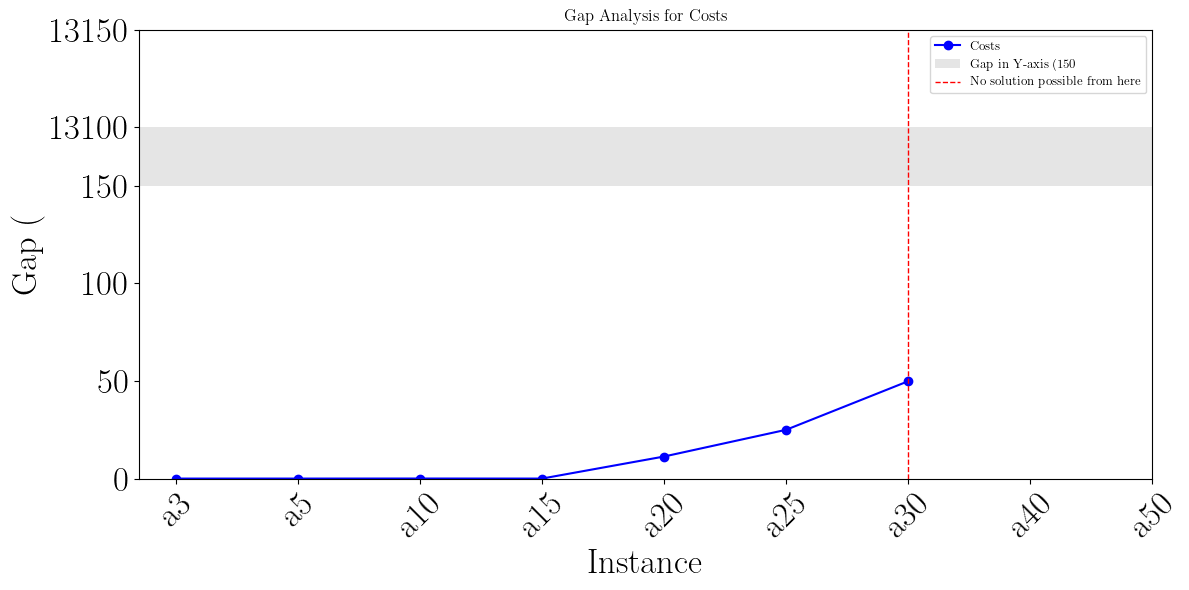

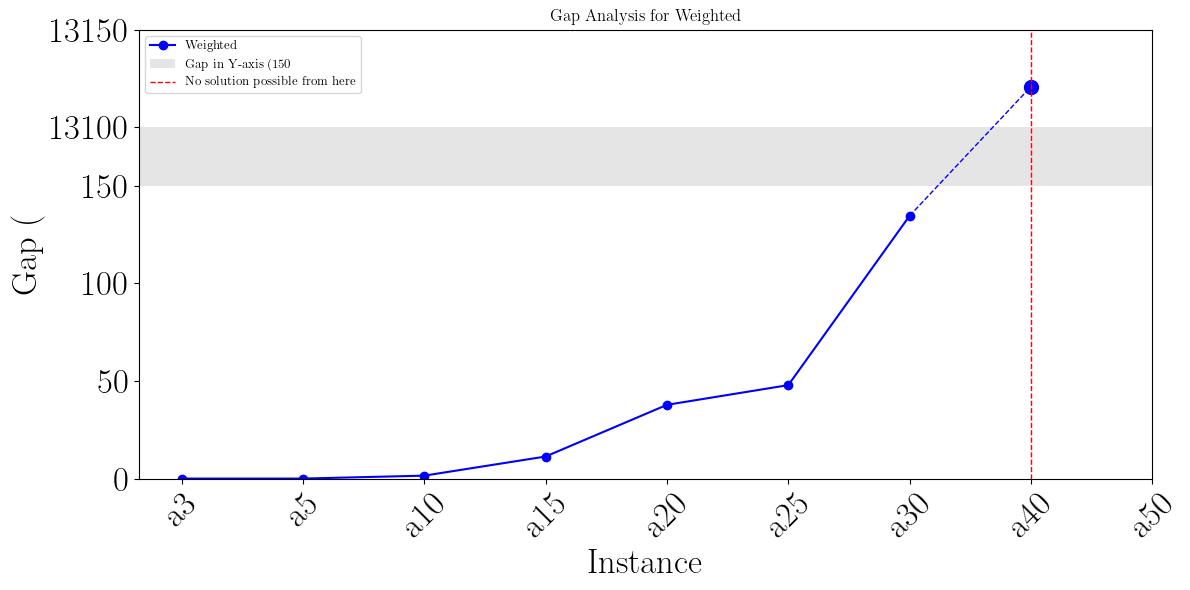

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Methods for analysis
methods = ["costs", "weighted"]

# Loop through both methods
for method in methods:
    method_data = df[df["Method"] == method].reset_index(drop=True)

    # Check for the first instance where no solution is possible
    first_missing_solution = method_data[method_data["Missing Solution"]].iloc[0] if not method_data[method_data["Missing Solution"]].empty else None

    # If missing solutions exist, calculate the starting point for the red dashed line
    if first_missing_solution is not None:
        cutoff_instance = first_missing_solution["Instance"]
        cutoff_index = all_instances.index(cutoff_instance)
        cutoff_x = cutoff_index - 1  # The instance before
        # Filter for instances up to the last valid instance
        method_data = method_data[method_data["Instance_Sort"] < first_missing_solution["Instance_Sort"]]
    else:
        cutoff_x = None

    # Prepare data
    y = method_data["Gap (%)"].fillna(0).astype(float)  # Replace missing values with 0
    x_positions = [all_instances.index(instance) for instance in method_data["Instance"]]

    # Separate data for the gap
    y_before_gap = y[y <= 150]
    y_after_gap = y[y > 13100]
    x_before_gap = x_positions[:len(y_before_gap)]
    x_after_gap = x_positions[-len(y_after_gap):]

    # Custom transform for y-axis to minimize the gap
    def custom_y_axis_transform(y_values):
        transformed = []
        for y_val in y_values:
            if y_val <= 150:
                transformed.append(y_val)  # Normal scale
            elif y_val > 150 and y_val <= 13100:
                transformed.append(180)  # Minimized gap region (slightly larger now)
            else:
                transformed.append(180 + (y_val - 13100))  # Normal scale resumes
        return np.array(transformed)

    # Transform y values
    y_transformed = custom_y_axis_transform(y)

    # Create the plot
    plt.figure(figsize=(12, 6))

    # Plot points before the gap
    if len(x_before_gap) > 0 and len(y_before_gap) > 0:
        plt.plot(x_before_gap, custom_y_axis_transform(y_before_gap), marker="o", label=f"{method.capitalize()}", color="blue")

    # Plot points after the gap
    if len(x_after_gap) > 0 and len(y_after_gap) > 0:
        plt.plot(x_after_gap, custom_y_axis_transform(y_after_gap), marker="o", color="blue", markersize=10)

        # Draw a direct dashed connection between the last point before the gap and the first point after the gap
        plt.plot(
            [x_before_gap[-1], x_after_gap[0]],  # X-coordinates of the dashed segment
            [custom_y_axis_transform([y_before_gap.iloc[-1]])[0], custom_y_axis_transform([y_after_gap.iloc[0]])[0]],  # Y-coordinates transformed
            linestyle="--",
            color="blue",
            linewidth=1,
        )

    # Highlight the minimal gap
    plt.axhspan(150, 180, facecolor="grey", alpha=0.2, label="Gap in Y-axis (150% to 13100%)")

    # Set custom Y-axis ticks and labels
    plt.yticks(
        list(range(0, 151, 50)) + [180, 180 + 50],  # Include 150%, gap marker (180), and high values
        labels=[str(i) for i in range(0, 151, 50)] + ["13100", "13150"]
    )

    # Set custom limits
    plt.ylim(0, 180 + 50)

    # Draw the red dashed line at the correct position
    if cutoff_x is not None and cutoff_x >= 0:
        plt.axvline(x=cutoff_x, color="red", linestyle="--", linewidth=1, label="No solution possible from here")

    # Label axes
    plt.ylabel("Gap (%)")
    plt.xlabel("Instance")
    plt.xticks(range(len(all_instances)), all_instances, rotation=45)

    # Add title and legend
    plt.title(f"Gap Analysis for {method.capitalize()}")
    plt.legend()
    plt.tight_layout()
    plt.show()

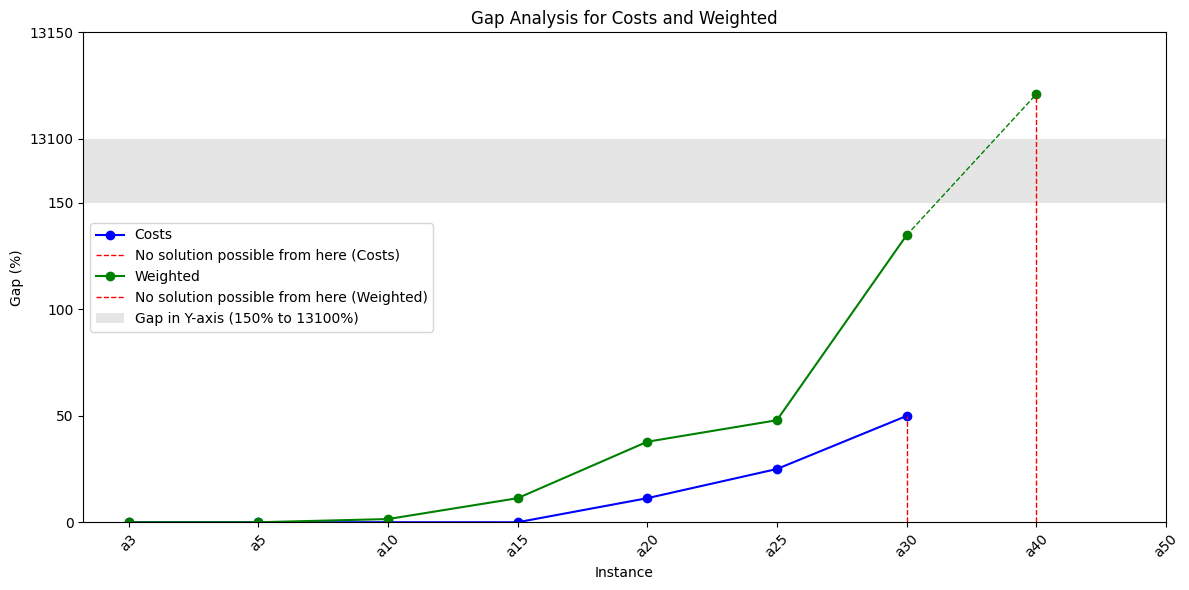

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
plt.figure(figsize=(12, 6))

# Custom transform for y-axis to minimize the gap
def custom_y_axis_transform(y_values):
    transformed = []
    for y_val in y_values:
        if y_val <= 150:
            transformed.append(y_val)  # Normal scale
        elif y_val > 150 and y_val <= 13100:
            transformed.append(180)  # Minimized gap region (slightly larger now)
        else:
            transformed.append(180 + (y_val - 13100))  # Normal scale resumes
    return np.array(transformed)

# Methods for analysis
methods = ["costs", "weighted"]

# Colors for the lines
method_colors = {"costs": "blue", "weighted": "green"}

# Loop through both methods
for method in methods:
    method_data = df[df["Method"] == method].reset_index(drop=True)

    # Check for the first instance where no solution is possible
    first_missing_solution = method_data[method_data["Missing Solution"]].iloc[0] if not method_data[method_data["Missing Solution"]].empty else None

    # If missing solutions exist, calculate the starting point for the red dashed line
    if first_missing_solution is not None:
        cutoff_instance = first_missing_solution["Instance"]
        cutoff_index = all_instances.index(cutoff_instance)
        cutoff_x = cutoff_index - 1  # The instance before
        # Filter for instances up to the last valid instance
        method_data = method_data[method_data["Instance_Sort"] < first_missing_solution["Instance_Sort"]]
    else:
        cutoff_x = None

    # Prepare data
    y = method_data["Gap (%)"].replace("-", 0).astype(float)  # Replace missing values with 0
    x_positions = [all_instances.index(instance) for instance in method_data["Instance"]]

    # Separate data for the gap
    y_before_gap = y[y <= 150]
    y_after_gap = y[y > 13100]
    x_before_gap = x_positions[:len(y_before_gap)]
    x_after_gap = x_positions[-len(y_after_gap):]

    # Plot points before the gap
    if len(x_before_gap) > 0 and len(y_before_gap) > 0:
        plt.plot(x_before_gap, custom_y_axis_transform(y_before_gap), marker="o", label=f"{method.capitalize()}", color=method_colors[method])

    # Plot points after the gap
    if len(x_after_gap) > 0 and len(y_after_gap) > 0:
        plt.plot(x_after_gap, custom_y_axis_transform(y_after_gap), marker="o", color=method_colors[method])

        # Draw a direct dashed connection between the last point before the gap and the first point after the gap
        plt.plot(
            [x_before_gap[-1], x_after_gap[0]],  # X-coordinates of the dashed segment
            [custom_y_axis_transform([y_before_gap.iloc[-1]])[0], custom_y_axis_transform([y_after_gap.iloc[0]])[0]],  # Y-coordinates transformed
            linestyle="--",
            color="green",
            linewidth=1,
        )

    # Draw the red dashed line at the correct position for this method
    if cutoff_x is not None and cutoff_x >= 0:
        # Determine the height of the dashed line
        y_before_gap_transformed = custom_y_axis_transform(y_before_gap) if not y_before_gap.empty else [0]
        y_after_gap_transformed = custom_y_axis_transform(y_after_gap) if not y_after_gap.empty else [0]
        
        last_valid_point = max(max(y_before_gap_transformed), max(y_after_gap_transformed))
        plt.axvline(
            x=cutoff_x,
            color="red",
            linestyle="--",
            linewidth=1,
            label=f"No solution possible from here ({method.capitalize()})",
            ymax=last_valid_point / (180 + 50),  # Scale the dashed line height
        )

# Highlight the minimal gap
plt.axhspan(150, 180, facecolor="grey", alpha=0.2, label="Gap in Y-axis (150% to 13100%)")

# Set custom Y-axis ticks and labels
plt.yticks(
    list(range(0, 151, 50)) + [180, 180 + 50],  # Include 150%, gap marker (180), and high values
    labels=[str(i) for i in range(0, 151, 50)] + ["13100", "13150"]
)

# Set custom limits
plt.ylim(0, 180 + 50)

# Label axes
plt.ylabel("Gap (%)")
plt.xlabel("Instance")
plt.xticks(range(len(all_instances)), all_instances, rotation=45)

# Add title and legend
plt.title("Gap Analysis for Costs and Weighted")
plt.legend()
plt.tight_layout()
plt.show()

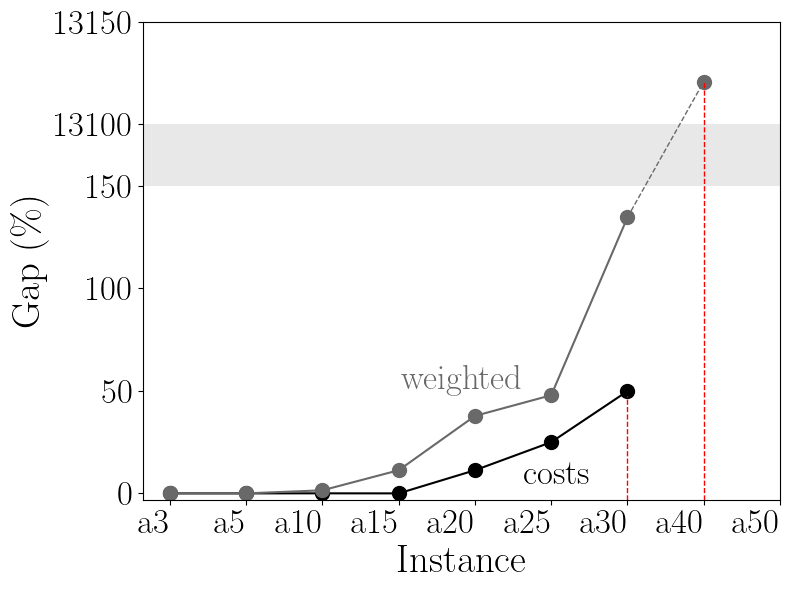

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

rcParams.update({
    "text.usetex": True,  # LaTeX-Schriftart verwenden
    "font.family": "serif",  # Serifen-Schrift (wie in wissenschaftlichen Dokumenten)
    "font.size": 10,  # Grundschriftgröße
    "axes.labelsize": 28,  # Achsenbeschriftung
    "xtick.labelsize": 25,  # Größe der x-Ticks
    "ytick.labelsize": 25,  # Größe der y-Ticks
})


# Create the plot
plt.figure(figsize=(8, 6))

# Custom transform for y-axis to minimize the gap
def custom_y_axis_transform(y_values):
    transformed = []
    for y_val in y_values:
        if y_val <= 150:
            transformed.append(y_val)  # Normal scale
        elif y_val > 150 and y_val <= 13100:
            transformed.append(180)  # Minimized gap region
        else:
            transformed.append(180 + (y_val - 13100))  # Normal scale resumes
    return np.array(transformed)

# Methods for analysis
methods = ["costs", "weighted"]

# Colors for the lines
method_colors = {"costs": "black", "weighted": "dimgray"}  # Subtle grayscale colors

# Loop through both methods
for method in methods:
    method_data = df[df["Method"] == method].reset_index(drop=True)

    # Check for the first instance where no solution is possible
    first_missing_solution = method_data[method_data["Missing Solution"]].iloc[0] if not method_data[method_data["Missing Solution"]].empty else None

    # If missing solutions exist, calculate the starting point for the red dashed line
    if first_missing_solution is not None:
        cutoff_instance = first_missing_solution["Instance"]
        cutoff_index = all_instances.index(cutoff_instance)
        cutoff_x = cutoff_index - 1  # The instance before
        # Filter for instances up to the last valid instance
        method_data = method_data[method_data["Instance_Sort"] < first_missing_solution["Instance_Sort"]]
    else:
        cutoff_x = None

    # Prepare data
    y = method_data["Gap (%)"].replace("-", 0).astype(float)  # Replace missing values with 0
    x_positions = [all_instances.index(instance) for instance in method_data["Instance"]]

    # Separate data for the gap
    y_before_gap = y[y <= 150]
    y_after_gap = y[y > 13100]
    x_before_gap = x_positions[:len(y_before_gap)]
    x_after_gap = x_positions[-len(y_after_gap):]

    # Plot points before the gap
    if len(x_before_gap) > 0 and len(y_before_gap) > 0:
        plt.plot(x_before_gap, custom_y_axis_transform(y_before_gap), marker="o", label=f"{method.capitalize()}", color=method_colors[method], markersize=10)

    # Plot points after the gap
    if len(x_after_gap) > 0 and len(y_after_gap) > 0:
        plt.plot(x_after_gap, custom_y_axis_transform(y_after_gap), marker="o", color=method_colors[method], markersize=10)

        # Draw a direct dashed connection between the last point before the gap and the first point after the gap
        plt.plot(
            [x_before_gap[-1], x_after_gap[0]],  # X-coordinates of the dashed segment
            [custom_y_axis_transform([y_before_gap.iloc[-1]])[0], custom_y_axis_transform([y_after_gap.iloc[0]])[0]],  # Y-coordinates transformed
            linestyle="--",
            color=method_colors[method],
            linewidth=1,
        )

    # Draw the red dashed line at the correct position for this method
    if cutoff_x is not None and cutoff_x >= 0:
        # Determine the height of the dashed line
        y_before_gap_transformed = custom_y_axis_transform(y_before_gap) if not y_before_gap.empty else [0]
        y_after_gap_transformed = custom_y_axis_transform(y_after_gap) if not y_after_gap.empty else [0]

        last_valid_point = max(max(y_before_gap_transformed), max(y_after_gap_transformed))
        plt.axvline(
            x=cutoff_x,
            color="red",
            linestyle="--",
            linewidth=1,
            label=f"No solution possible from here ({method.capitalize()})",
            ymax=last_valid_point / (180 + 50),  # Scale the dashed line height
        )

# Highlight the minimal gap
plt.axhspan(150, 180, facecolor="lightgrey", alpha=0.5, label="Gap in Y-axis (150% to 13100%)")

# Set custom Y-axis ticks and labels
plt.yticks(
    list(range(0, 151, 50)) + [180, 180 + 50],  # Include 150%, gap marker (180), and high values
    labels=[str(i) for i in range(0, 151, 50)] + ["13100", "13150"]
)

# Set custom limits
plt.ylim(-3, 180 + 50)

# Label axes
plt.ylabel("Gap (\%)")
plt.xlabel("Instance")
plt.xticks(range(len(all_instances)), all_instances, rotation=0, ha="right")

# add method name to the plot
plt.text(0.65, 0.05, "costs", color="black", transform=plt.gca().transAxes, ha="center", va="center", size=25)
plt.text(0.5, 0.25, "weighted", color="dimgray", transform=plt.gca().transAxes, ha="center", va="center", size=25)


# Add title and legend
#plt.title("Gap Analysis for Costs and Weighted", pad=15)
#plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.savefig("gap_analysis.pdf", bbox_inches="tight")

# Show plot
plt.show()